In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import shap

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text


from pylab import rcParams

/opt/anaconda3/envs/AI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%matplotlib inline

In [4]:
# Set display options to show the full result
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [5]:
# Load the DataFrame from the pickle file
pickle_file_path = "project_folder/Wind/Outputs/IEA15MW.pkl"
df = pd.read_pickle(pickle_file_path)

In [6]:
for col in df.columns:
    print(col)

Time_[s]
Wind1VelX_[m/s]
Wind1VelY_[m/s]
Wind1VelZ_[m/s]
Azimuth_[deg]
BldPitch1_[deg]
BldPitch2_[deg]
BldPitch3_[deg]
GenSpeed_[rpm]
LSSTipMya_[kN-m]
LSSTipMys_[kN-m]
LSSTipMza_[kN-m]
LSSTipMzs_[kN-m]
LSShftFxa_[kN]
LSShftFxs_[kN]
LSShftFya_[kN]
LSShftFys_[kN]
LSShftFza_[kN]
LSShftFzs_[kN]
NacYaw_[deg]
NcIMURAys_[deg/s^2]
NcIMUTAxs_[m/s^2]
NcIMUTAzs_[m/s^2]
PtfmHeave_[m]
PtfmPitch_[deg]
PtfmRoll_[deg]
PtfmSurge_[m]
PtfmSway_[m]
PtfmYaw_[deg]
RootFxb1_[kN]
RootFxb2_[kN]
RootFxb3_[kN]
RootFxc1_[kN]
RootFxc2_[kN]
RootFxc3_[kN]
RootFyb1_[kN]
RootFyb2_[kN]
RootFyb3_[kN]
RootFyc1_[kN]
RootFyc2_[kN]
RootFyc3_[kN]
RootFzb1_[kN]
RootFzb2_[kN]
RootFzb3_[kN]
RootFzc1_[kN]
RootFzc2_[kN]
RootFzc3_[kN]
RootMxb1_[kN-m]
RootMxb2_[kN-m]
RootMxb3_[kN-m]
RootMxc1_[kN-m]
RootMxc2_[kN-m]
RootMxc3_[kN-m]
RootMyb1_[kN-m]
RootMyb2_[kN-m]
RootMyb3_[kN-m]
RootMyc1_[kN-m]
RootMyc2_[kN-m]
RootMyc3_[kN-m]
RootMzb1_[kN-m]
RootMzb2_[kN-m]
RootMzb3_[kN-m]
RootMzc1_[kN-m]
RootMzc2_[kN-m]
RootMzc3_[kN-m]
RotSpeed_[rpm

In [7]:
df['RtFldCp_[-]'].describe()

count    40001.000000
mean         0.278229
std          0.087300
min          0.138805
25%          0.217415
50%          0.254685
75%          0.315847
max          0.673380
Name: RtFldCp_[-], dtype: float64

In [12]:
df['Wind1VelX_[m/s]'].describe()

count    40001.000000
mean        12.987319
std          2.269720
min          5.548587
25%         11.632878
50%         13.192506
75%         14.475264
max         20.544224
Name: Wind1VelX_[m/s], dtype: float64

<Axes: >

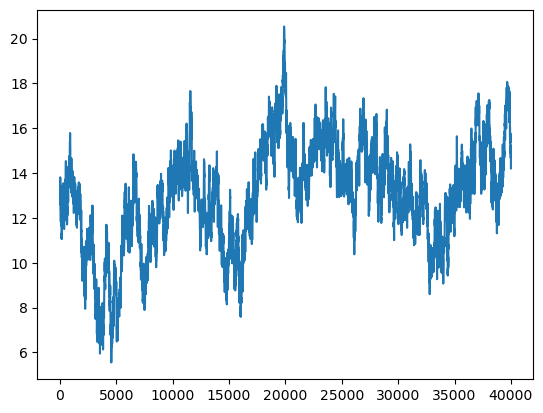

In [13]:
df['Wind1VelX_[m/s]'].plot()

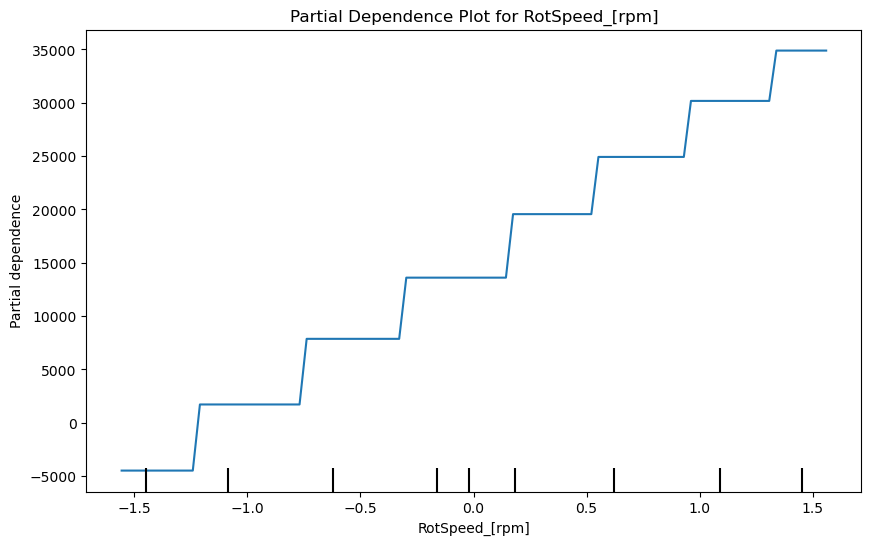

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay

# Assuming df is your DataFrame

# Select relevant columns
input_features = ['RotSpeed_[rpm]']
target_variable = 'GenPwr_[kW]'

# Extract input variables (X) and output variable (y)
X = df[input_features]
y = df[target_variable]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the input data
scaler_X = StandardScaler()
X_train_normalized = scaler_X.fit_transform(X_train)
X_test_normalized = scaler_X.transform(X_test)

# Train a Decision Tree Regressor model
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train_normalized, y_train)

# Generate Partial Dependence Plot (PDP)
features = [0]  # Index of 'RotSpeed_[rpm]' in the input features
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(tree_model, X_train_normalized, features, feature_names=input_features, ax=ax)
plt.title('Partial Dependence Plot for RotSpeed_[rpm]')
plt.show()